In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime, timedelta
import string
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import lightgbm as lgb


In [2]:
unbalanced_data = pd.read_csv('E:/tvb_25/datasets/Twitter Analysis.csv')
unbalanced_data.head()

,Unnamed: 0,majority_target,statement,BinaryNumTarget,tweet,followers_count,friends_count,favourites_count,statuses_count,listed_count,...,determiners,conjunctions,dots,exclamation,questions,ampersand,capitals,digits,long_word_freq,short_word_freq
0,0,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders - 6 Month Update\n\nInfl...,4262.0,3619.0,34945.0,16423.0,44.0,...,0,0,5,0,1,0,33,3,5,19
1,1,True,End of eviction moratorium means millions of A...,1.0,@S0SickRick @Stairmaster_ @6d6f636869 Not as m...,1393.0,1621.0,31436.0,37184.0,64.0,...,0,2,1,0,0,0,14,0,2,34
2,2,True,End of eviction moratorium means millions of A...,1.0,THE SUPREME COURT is siding with super rich pr...,9.0,84.0,219.0,1184.0,0.0,...,0,1,0,0,0,0,3,0,4,10
3,3,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders\n\nBroken campaign promi...,4262.0,3619.0,34945.0,16423.0,44.0,...,0,1,3,0,0,1,6,8,1,30
4,4,True,End of eviction moratorium means millions of A...,1.0,@OhComfy I agree. The confluence of events rig...,70.0,166.0,15282.0,2194.0,0.0,...,0,1,3,0,1,0,11,3,2,19


In [3]:
unbalanced_data.describe()

,Unnamed: 0,BinaryNumTarget,followers_count,friends_count,favourites_count,statuses_count,listed_count,following,BotScore,BotScoreBinary,...,determiners,conjunctions,dots,exclamation,questions,ampersand,capitals,digits,long_word_freq,short_word_freq
count,134198.00000,134198.000000,1.341980e+05,134198.000000,1.341980e+05,1.341980e+05,134198.000000,134198.0,134198.000000,134198.000000,...,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000,134198.000000
mean,67098.50000,0.513644,1.129308e+04,1893.454455,3.298123e+04,3.419576e+04,73.300198,0.0,0.059106,0.032355,...,0.135583,1.003495,2.366116,0.259408,0.307151,0.121537,12.831905,3.559494,2.249557,21.438658
std,38739.77005,0.499816,4.374971e+05,6997.695671,6.878021e+04,7.510120e+04,1083.274277,0.0,0.167819,0.176942,...,0.379235,1.086844,2.140459,0.903957,0.774367,0.453865,15.557524,6.674458,2.912136,9.625147
min,0.00000,0.000000,0.000000e+00,0.000000,0.000000e+00,1.000000e+00,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33549.25000,0.000000,7.000000e+01,168.000000,1.356000e+03,3.046000e+03,0.000000,0.0,0.030000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,6.000000,0.000000,1.000000,14.000000
50%,67098.50000,1.000000,3.540000e+02,567.000000,8.377000e+03,1.101900e+04,2.000000,0.0,0.030000,0.000000,...,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,10.000000,2.000000,2.000000,21.000000
75%,100647.75000,1.000000,1.573000e+03,1726.000000,3.352650e+04,3.357375e+04,11.000000,0.0,0.030000,0.000000,...,0.000000,2.000000,3.000000,0.000000,0.000000,0.000000,15.000000,4.000000,3.000000,28.000000
max,134197.00000,1.000000,1.306019e+08,586901.000000,1.765080e+06,2.958918e+06,222193.000000,0.0,1.000000,1.000000,...,5.000000,13.000000,50.000000,66.000000,43.000000,13.000000,250.000000,138.000000,47.000000,164.000000


In [4]:
unbalanced_data.columns

Index(['Unnamed: 0', 'majority_target', 'statement', 'BinaryNumTarget',
       'tweet', 'followers_count', 'friends_count', 'favourites_count',
       'statuses_count', 'listed_count', 'following', 'embeddings', 'BotScore',
       'BotScoreBinary', 'cred', 'normalize_influence', 'mentions', 'quotes',
       'replies', 'retweets', 'favourites', 'hashtags', 'URLs', 'unique_count',
       'total_count', 'ORG_percentage', 'NORP_percentage', 'GPE_percentage',
       'PERSON_percentage', 'MONEY_percentage', 'DATE_percentage',
       'CARDINAL_percentage', 'PERCENT_percentage', 'ORDINAL_percentage',
       'FAC_percentage', 'LAW_percentage', 'PRODUCT_percentage',
       'EVENT_percentage', 'TIME_percentage', 'LOC_percentage',
       'WORK_OF_ART_percentage', 'QUANTITY_percentage', 'LANGUAGE_percentage',
       'Word count', 'Max word length', 'Min word length',
       'Average word length', 'present_verbs', 'past_verbs', 'adjectives',
       'adverbs', 'adpositions', 'pronouns', 'TOs', 'deter

In [5]:
# Changing column names so they are all equal (adding _ for spaces)
unbalanced_data.columns = unbalanced_data.columns.str.replace(' ', '_')

In [6]:
unbalanced_data.columns

Index(['Unnamed:_0', 'majority_target', 'statement', 'BinaryNumTarget',
       'tweet', 'followers_count', 'friends_count', 'favourites_count',
       'statuses_count', 'listed_count', 'following', 'embeddings', 'BotScore',
       'BotScoreBinary', 'cred', 'normalize_influence', 'mentions', 'quotes',
       'replies', 'retweets', 'favourites', 'hashtags', 'URLs', 'unique_count',
       'total_count', 'ORG_percentage', 'NORP_percentage', 'GPE_percentage',
       'PERSON_percentage', 'MONEY_percentage', 'DATE_percentage',
       'CARDINAL_percentage', 'PERCENT_percentage', 'ORDINAL_percentage',
       'FAC_percentage', 'LAW_percentage', 'PRODUCT_percentage',
       'EVENT_percentage', 'TIME_percentage', 'LOC_percentage',
       'WORK_OF_ART_percentage', 'QUANTITY_percentage', 'LANGUAGE_percentage',
       'Word_count', 'Max_word_length', 'Min_word_length',
       'Average_word_length', 'present_verbs', 'past_verbs', 'adjectives',
       'adverbs', 'adpositions', 'pronouns', 'TOs', 'deter

## For this classification task, the target variable is BinaryNumTarget
- that represents a binary value 1 = human, 2 = bot

In [8]:
# Targret variable
unbalanced_data['BinaryNumTarget'].value_counts()

BinaryNumTarget
1.0    68930
0.0    65268
Name: count, dtype: int64

In [10]:
# Check for missing values to fill / replace
unbalanced_data.isnull().sum()

Unnamed:_0         0
majority_target    0
statement          0
BinaryNumTarget    0
tweet              0
                  ..
ampersand          0
capitals           0
digits             0
long_word_freq     0
short_word_freq    0
Length: 64, dtype: int64

### Adding real twitter metadata variables to the dataset (found in Diego's branch)

In [11]:
import numpy as np

# Temporal features
temporal_features = {
    "avg_time_between_tweets_seconds": np.nan,  # Numerical
    "median_time_between_tweets_seconds": np.nan,  # Numerical
    "tweet_frequency_per_day": 0.0,  # Numerical
    "most_active_hour": 0,  # Numerical (0-23)
    "weekend_tweet_ratio": 0.0,  # Numerical (0-1)
    "max_tweets_per_hour": 0,  # Numerical
    "avg_tweets_per_active_hour": 0.0  # Numerical
}

# Engagement features
engagement_features = {
    "avg_likes_per_tweet": 0.0,  # Numerical
    "avg_retweets_per_tweet": 0.0,  # Numerical
    "avg_replies_per_tweet": 0.0,  # Numerical
    "avg_views_per_tweet": 0.0,  # Numerical
    "median_likes_per_tweet": 0.0,  # Numerical
    "median_retweets_per_tweet": 0.0,  # Numerical
    "pct_tweets_with_media": 0.0,  # Numerical (percentage)
    "pct_tweets_with_video": 0.0,  # Numerical (percentage)
    "pct_tweets_with_hashtags": 0.0,  # Numerical (percentage)
    "pct_tweets_with_urls": 0.0,  # Numerical (percentage)
    "pct_retweets": 0.0,  # Numerical (percentage)
    "pct_replies": 0.0,  # Numerical (percentage)
    "pct_tweets_with_spam_keywords": 0.0  # Numerical (percentage)
}

# Tweet-level features
tweet_features = {
    "tweet_id": [""] * len(unbalanced_data),  # String/Categorical
    "username": [""] * len(unbalanced_data),  # String/Categorical
    "handle": [""] * len(unbalanced_data),  # String/Categorical
    "tweet_text": [""] * len(unbalanced_data),  # String/Text
    "tweet_url": [""] * len(unbalanced_data),  # String/URL
    "timestamp": [""] * len(unbalanced_data),  # String/Datetime
    "source": [""] * len(unbalanced_data),  # String/Categorical
    "lang": [None] * len(unbalanced_data),  # String/Categorical
    "reply_count": 0,  # Numerical - scalar broadcasts to all rows
    "retweet_count": 0,
    "like_count": 0,
    "view_count": 0,
    "quote_count": 0,
    "bookmark_count": 0,
    "hashtag_count": 0,
    "mention_count": 0,
    "url_count": 0,
    "media_count": 0,
    "text_length": 0,
    "word_count": 0,
    "emoji_count": 0,
    "exclamation_count": 0,
    "question_count": 0,
    "uppercase_ratio": 0.0,
    "punctuation_ratio": 0.0,
    "digit_ratio": 0.0,
    "is_retweet": False,  # Boolean - scalar broadcasts
    "is_reply": False,
    "is_quote": False,
    "has_media": False,
    "has_video": False,
    "has_hashtags": False,
    "has_mentions": False,
    "has_urls": False,
    "possibly_sensitive": False,
    "contains_spam_keywords": False,
    "hashtags": [[] for _ in range(len(unbalanced_data))],  # List - need unique list per row
    "mentions": [[] for _ in range(len(unbalanced_data))],
    "urls": [[] for _ in range(len(unbalanced_data))],
    "hour_of_day": 0,
    "day_of_week": 0,
    "is_weekend": False,
    "scraped_at": [""] * len(unbalanced_data)
}

# User-level/Account metadata features
user_features = {
    "display_name": [""] * len(unbalanced_data),  # String/Categorical
    "bio": [""] * len(unbalanced_data),  # String/Text
    "location": [None] * len(unbalanced_data),  # String/Categorical (can be null)
    "website": [None] * len(unbalanced_data),  # String/URL (can be null)
    "created_at": [""] * len(unbalanced_data),  # String/Datetime
    "following_count": 0,  # Numerical
    "tweet_count": 0,  # Numerical
    "account_age_days": 0,  # Numerical
    "description_length": 0,  # Numerical
    "name_length": 0,  # Numerical
    "screen_name_length": 0,  # Numerical
    "followers_to_following_ratio": 0.0,  # Numerical
    "verified": False,  # Boolean
    "has_description": False,  # Boolean
    "has_url": False,  # Boolean
    "has_location": False,  # Boolean
    "default_profile_image": False,  # Boolean
    "profile_scraped_at": [""] * len(unbalanced_data)  # String/Datetime
}

# Combine all features
all_features = {**temporal_features, **engagement_features, **tweet_features, **user_features}

# Check for duplicates and add features
existing_columns = set(unbalanced_data.columns)
features_added = 0
features_skipped = []

for feature_name, feature_value in all_features.items():
    if feature_name not in existing_columns:
        unbalanced_data[feature_name] = feature_value
        features_added += 1
    else:
        features_skipped.append(feature_name)

print(f"{features_added} new columns")
print(f"{len(features_skipped)} duplicate columns: {features_skipped}")
print(f"New shape: {unbalanced_data.shape}")

79 new columns
2 duplicate columns: ['hashtags', 'mentions']
New shape: (134198, 143)


In [12]:
unbalanced_data.shape

(134198, 143)

In [13]:
unbalanced_data.isnull().sum()

Unnamed:_0               0
majority_target          0
statement                0
BinaryNumTarget          0
tweet                    0
                        ..
has_description          0
has_url                  0
has_location             0
default_profile_image    0
profile_scraped_at       0
Length: 143, dtype: int64

## Filling synthetic data with values

In [14]:
# Find columns with different types of "empty" values
empty_value_cols = []

for col in unbalanced_data.columns:
    # Check for actual nulls
    if unbalanced_data[col].isnull().any():
        empty_value_cols.append((col, 'null/NaN'))
    # Check for empty strings
    elif unbalanced_data[col].dtype == 'object':
        if (unbalanced_data[col] == "").any():
            empty_value_cols.append((col, 'empty string'))
    # Check for all zeros (numeric columns only)
    elif np.issubdtype(unbalanced_data[col].dtype, np.number):
        if (unbalanced_data[col] == 0).all():
            empty_value_cols.append((col, 'all zeros'))
    # Check for all False (boolean columns)
    elif unbalanced_data[col].dtype == 'bool':
        if (~unbalanced_data[col]).all():  # All False
            empty_value_cols.append((col, 'all False'))

print(f"Found {len(empty_value_cols)} columns with placeholder/empty values:\n")
for col, val_type in empty_value_cols:
    print(f"  - {col}: {val_type}")

Found 79 columns with placeholder/empty values:

  - following: all zeros
  - avg_time_between_tweets_seconds: null/NaN
  - median_time_between_tweets_seconds: null/NaN
  - tweet_frequency_per_day: all zeros
  - most_active_hour: all zeros
  - weekend_tweet_ratio: all zeros
  - max_tweets_per_hour: all zeros
  - avg_tweets_per_active_hour: all zeros
  - avg_likes_per_tweet: all zeros
  - avg_retweets_per_tweet: all zeros
  - avg_replies_per_tweet: all zeros
  - avg_views_per_tweet: all zeros
  - median_likes_per_tweet: all zeros
  - median_retweets_per_tweet: all zeros
  - pct_tweets_with_media: all zeros
  - pct_tweets_with_video: all zeros
  - pct_tweets_with_hashtags: all zeros
  - pct_tweets_with_urls: all zeros
  - pct_retweets: all zeros
  - pct_replies: all zeros
  - pct_tweets_with_spam_keywords: all zeros
  - tweet_id: empty string
  - username: empty string
  - handle: empty string
  - tweet_text: empty string
  - tweet_url: empty string
  - timestamp: empty string
  - source

In [1]:
# Assigning random countries to the variables
RNG = np.random.default_rng(7)

# make sure we can assign strings as column might not allow dtype
unbalanced_data["location"] = unbalanced_data["location"].astype(object)

countries = [
    "Spain","France","Germany","Italy","Portugal","Netherlands","Belgium",
    "Sweden","Norway","Denmark","Finland","Poland","Greece","Ireland","United Kingdom",
    "Austria","Switzerland","Czechia","Hungary","Romania","Bulgaria","Croatia",
    "Serbia","Slovenia","Slovakia","Ukraine"
]

# Percentage of likely-hood for a person to be from a country [spain = 20% more likely]
weights = np.array([
    20,10,10,8,5,5,4, 4,3,3,3,6,5,3,8, 3,3,3,3,3,2,2, 2,2,2,4
], dtype=float)
p = weights / weights.sum()

# assign independently per row
unbalanced_data["location"] = RNG.choice(countries, size=len(unbalanced_data), p=p)

# sanity check
print(unbalanced_data["location"].value_counts().head(10))


NameError: name 'np' is not defined

In [16]:
# Making 130k rng websites took too long
unbalanced_data.drop(columns=['website'], inplace=True, errors='ignore')

In [17]:
# Columns that are still null
null_cols = unbalanced_data.columns[unbalanced_data.isnull().any()].tolist()
print(null_cols)

['avg_time_between_tweets_seconds', 'median_time_between_tweets_seconds', 'lang']


## Variable hierarchy, and splitting
- Based on 2 academic papers
- Related to our problem

In [18]:
feature_hierarchy = {
    "CRITICAL - Account Metadata (User Identity)": [
        'followers_count', 'friends_count', 'following_count',
        'followers_to_following_ratio', 'statuses_count', 'tweet_count',
        'favourites_count', 'listed_count', 'account_age_days',
        'verified', 'default_profile_image', 'has_description',
        'has_url', 'has_location', 'BotScore'
    ],

    "CRITICAL - Temporal Behavior Patterns": [
        'tweet_frequency_per_day', 'avg_time_between_tweets_seconds',
        'median_time_between_tweets_seconds', 'most_active_hour',
        'weekend_tweet_ratio', 'max_tweets_per_hour',
        'avg_tweets_per_active_hour', 'hour_of_day', 'day_of_week'
    ],

    "HIGH - Engagement Patterns": [
        'avg_likes_per_tweet', 'avg_retweets_per_tweet', 'avg_replies_per_tweet',
        'avg_views_per_tweet', 'median_likes_per_tweet', 'median_retweets_per_tweet',
        'like_count', 'retweet_count', 'reply_count', 'view_count',
        'quote_count', 'bookmark_count'
    ],

    "HIGH - Content Behavior": [
        'pct_tweets_with_media', 'pct_tweets_with_video',
        'pct_tweets_with_hashtags', 'pct_tweets_with_urls',
        'pct_retweets', 'pct_replies', 'pct_tweets_with_spam_keywords',
        'has_media', 'has_video', 'has_hashtags', 'has_mentions', 'has_urls',
        'is_retweet', 'is_reply', 'is_quote'
    ],

    "MEDIUM - Text Characteristics": [
        'text_length', 'word_count', 'Word_count', 'Max_word_length',
        'Min_word_length', 'Average_word_length',
        'emoji_count', 'exclamation_count', 'question_count',
        'uppercase_ratio', 'punctuation_ratio', 'digit_ratio',
        'hashtag_count', 'mention_count', 'url_count', 'media_count'
    ],

    "MEDIUM - Linguistic Features": [
        'present_verbs', 'past_verbs', 'adjectives', 'adverbs',
        'adpositions', 'pronouns', 'TOs', 'determiners', 'conjunctions',
        'dots', 'exclamation', 'questions', 'ampersand', 'capitals', 'digits',
        'long_word_freq', 'short_word_freq'
    ],

    "MEDIUM - Named Entity Recognition": [
        'unique_count', 'total_count', 'ORG_percentage', 'NORP_percentage',
        'GPE_percentage', 'PERSON_percentage', 'MONEY_percentage',
        'DATE_percentage', 'CARDINAL_percentage', 'PERCENT_percentage',
        'ORDINAL_percentage', 'FAC_percentage', 'LAW_percentage',
        'PRODUCT_percentage', 'EVENT_percentage', 'TIME_percentage',
        'LOC_percentage', 'WORK_OF_ART_percentage', 'QUANTITY_percentage',
        'LANGUAGE_percentage'
    ],

    "LOW - Source/Platform": [
        'source', 'lang'
    ],

    "LOW - Content Flags": [
        'possibly_sensitive', 'contains_spam_keywords'
    ],

    "DERIVED - Existing Bot Scores": [
        'BotScoreBinary', 'cred', 'normalize_influence'
    ]
}


In [19]:
# Highest → lowest groups for modeling / reporting
priority_groups = [
    "CRITICAL - Source (Client App)",
    "CRITICAL - Account Metadata (User Identity)",
    "CRITICAL - Temporal Behavior Patterns",
    "HIGH - Engagement Patterns",
    "HIGH - Content Behavior",
    "MEDIUM - Text Characteristics",
    "MEDIUM - Linguistic Features",
    "MEDIUM - Named Entity Recognition",
    "LOW - Source/Platform",    # keep for back-compat, but 'source' moved out
    "LOW - Content Flags",
    "DERIVED - Existing Bot Scores",
]

# Build a new dict with `source` promoted to its own critical group
feature_hierarchy_ranked = {
    "CRITICAL - Source (Client App)": ["source"],
    **{k: feature_hierarchy[k] for k in [
        "CRITICAL - Account Metadata (User Identity)",
        "CRITICAL - Temporal Behavior Patterns",
        "HIGH - Engagement Patterns",
        "HIGH - Content Behavior",
        "MEDIUM - Text Characteristics",
        "MEDIUM - Linguistic Features",
        "MEDIUM - Named Entity Recognition",
        "LOW - Content Flags",
        "DERIVED - Existing Bot Scores",
    ]},
}

# Optional: flatten to a single ordered feature list
ordered_features = (
    feature_hierarchy_ranked["CRITICAL - Source (Client App)"] +
    feature_hierarchy_ranked["CRITICAL - Account Metadata (User Identity)"] +
    feature_hierarchy_ranked["CRITICAL - Temporal Behavior Patterns"] +
    feature_hierarchy_ranked["HIGH - Engagement Patterns"] +
    feature_hierarchy_ranked["HIGH - Content Behavior"] +
    feature_hierarchy_ranked["MEDIUM - Text Characteristics"] +
    feature_hierarchy_ranked["MEDIUM - Linguistic Features"] +
    feature_hierarchy_ranked["MEDIUM - Named Entity Recognition"] +
    feature_hierarchy["LOW - Source/Platform"] +           # (for 'lang' only now)
    feature_hierarchy_ranked["LOW - Content Flags"] +
    feature_hierarchy_ranked["DERIVED - Existing Bot Scores"]
)

print("=" * 80)
print("FEATURE HIERARCHY FOR BOT DETECTION")
print("=" * 80)
for category, features in feature_hierarchy.items():
    available = [f for f in features if f in unbalanced_data.columns]
    print(f"\n{category} ({len(available)} features):")
    for feat in available[:10]:  # Show first 10
        print(f"  • {feat}")
    if len(available) > 10:
        print(f"  ... and {len(available) - 10} more")

FEATURE HIERARCHY FOR BOT DETECTION

CRITICAL - Account Metadata (User Identity) (15 features):
  • followers_count
  • friends_count
  • following_count
  • followers_to_following_ratio
  • statuses_count
  • tweet_count
  • favourites_count
  • listed_count
  • account_age_days
  • verified
  ... and 5 more

CRITICAL - Temporal Behavior Patterns (9 features):
  • tweet_frequency_per_day
  • avg_time_between_tweets_seconds
  • median_time_between_tweets_seconds
  • most_active_hour
  • weekend_tweet_ratio
  • max_tweets_per_hour
  • avg_tweets_per_active_hour
  • hour_of_day
  • day_of_week

HIGH - Engagement Patterns (12 features):
  • avg_likes_per_tweet
  • avg_retweets_per_tweet
  • avg_replies_per_tweet
  • avg_views_per_tweet
  • median_likes_per_tweet
  • median_retweets_per_tweet
  • like_count
  • retweet_count
  • reply_count
  • view_count
  ... and 2 more

HIGH - Content Behavior (15 features):
  • pct_tweets_with_media
  • pct_tweets_with_video
  • pct_tweets_with_hashtag

In [20]:
print("\n" + "=" * 80)
print("CALCULATING FEATURE IMPORTANCE...")
print("=" * 80)

# Select numeric features for modeling
numeric_cols = unbalanced_data.select_dtypes(include=[np.number]).columns.tolist()

# Remove target and identifier columns
exclude_cols = ['BinaryNumTarget', 'Unnamed:_0',
                ]
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"\nUsing {len(feature_cols)} numeric features for importance calculation")

# Prepare data
X = unbalanced_data[feature_cols].fillna(0)
y = unbalanced_data['BinaryNumTarget']

# Train Random Forest
print("Training Random Forest classifier...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Get feature importances
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)


CALCULATING FEATURE IMPORTANCE...

Using 105 numeric features for importance calculation
Training Random Forest classifier...


In [21]:
unbalanced_data.shape

(134198, 142)

In [22]:
print("\n" + "=" * 80)
print("TOP 30 MOST IMPORTANT FEATURES FOR BOT DETECTION")
print("=" * 80)
for idx, row in importances.head(30).iterrows():
    print(f"{row['feature']:40s} | Importance: {row['importance']:.4f}")


TOP 30 MOST IMPORTANT FEATURES FOR BOT DETECTION
listed_count                             | Importance: 0.1028
URLs                                     | Importance: 0.0722
PERSON_percentage                        | Importance: 0.0683
hashtags                                 | Importance: 0.0550
followers_count                          | Importance: 0.0422
Word_count                               | Importance: 0.0383
normalize_influence                      | Importance: 0.0370
capitals                                 | Importance: 0.0340
pronouns                                 | Importance: 0.0319
CARDINAL_percentage                      | Importance: 0.0304
past_verbs                               | Importance: 0.0287
Average_word_length                      | Importance: 0.0284
cred                                     | Importance: 0.0263
statuses_count                           | Importance: 0.0261
favourites_count                         | Importance: 0.0252
MONEY_percentage    


GENERATING VISUALIZATIONS...

Features needed for 80% importance: 21
Features needed for 90% importance: 39


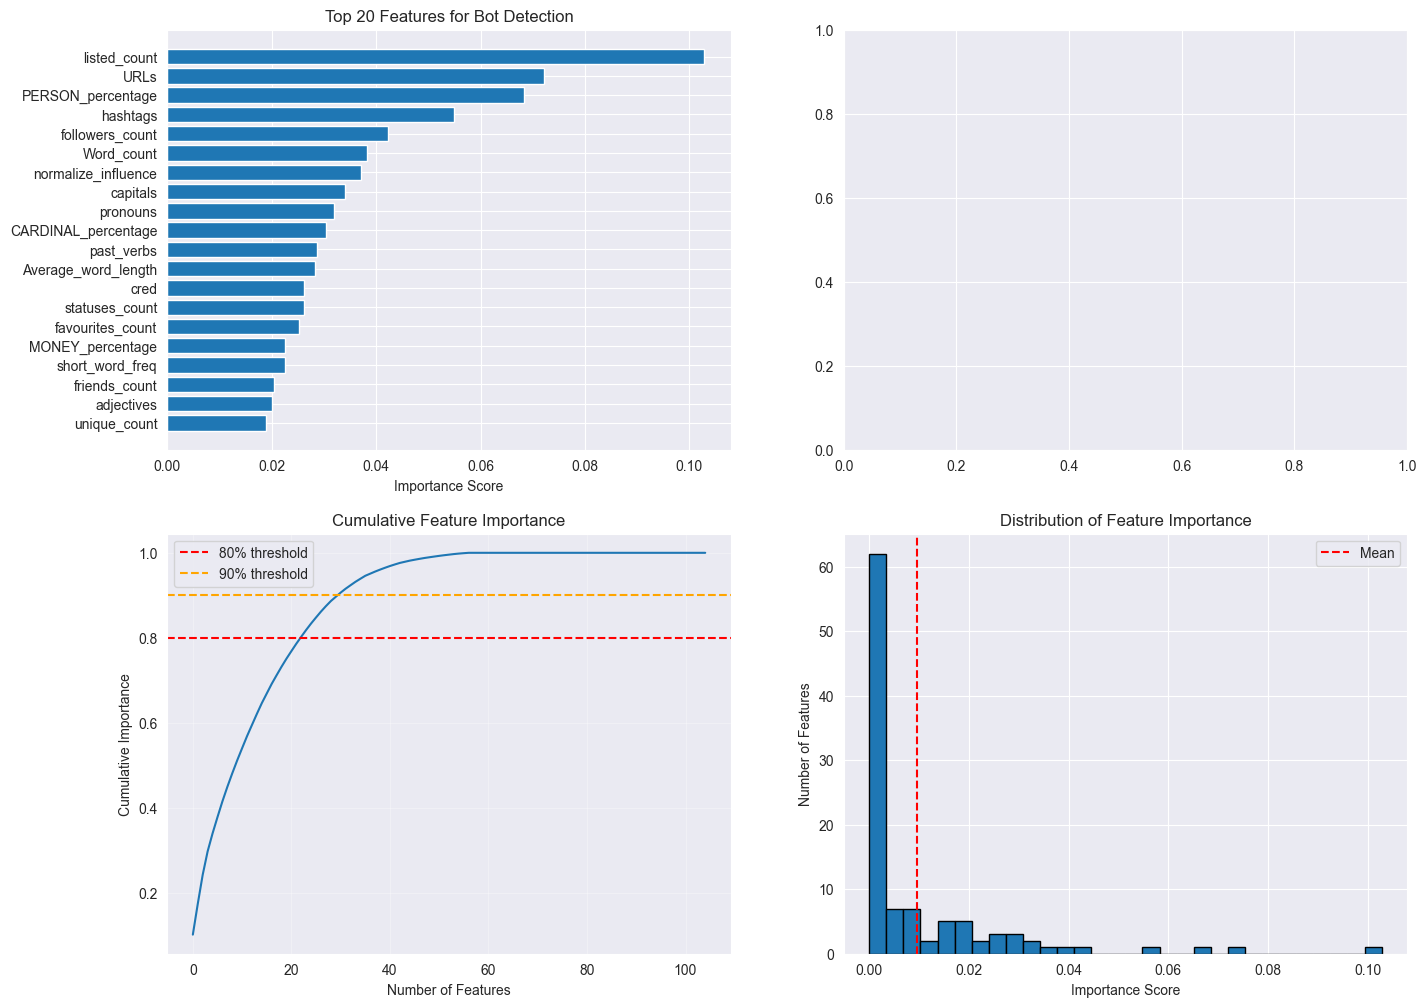

In [23]:
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS...")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Top 20 Features
ax1 = axes[0, 0]
top_20 = importances.head(20)
ax1.barh(range(len(top_20)), top_20['importance'])
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['feature'])
ax1.set_xlabel('Importance Score')
ax1.set_title('Top 20 Features for Bot Detection')
ax1.invert_yaxis()
ax3 = axes[1, 0]

cumsum = importances['importance'].cumsum()
ax3.plot(range(len(cumsum)), cumsum)
ax3.axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
ax3.axhline(y=0.9, color='orange', linestyle='--', label='90% threshold')
ax3.set_xlabel('Number of Features')
ax3.set_ylabel('Cumulative Importance')
ax3.set_title('Cumulative Feature Importance')
ax3.legend()
ax3.grid(True, alpha=0.3)

features_80 = (cumsum >= 0.8).idxmax() + 1
features_90 = (cumsum >= 0.9).idxmax() + 1
print(f"\nFeatures needed for 80% importance: {features_80}")
print(f"Features needed for 90% importance: {features_90}")

ax4 = axes[1, 1]
ax4.hist(importances['importance'], bins=30, edgecolor='black')
ax4.set_xlabel('Importance Score')
ax4.set_ylabel('Number of Features')
ax4.set_title('Distribution of Feature Importance')
ax4.axvline(x=importances['importance'].mean(), color='r', linestyle='--', label='Mean')
ax4.legend()

In [24]:
print(f"   • Use top {features_80} features to capture 80% of predictive power")
print(f"   • Use top {features_90} features to capture 90% of predictive power")
print(f"   • Total available features: {len(feature_cols)}")

   • Use top 21 features to capture 80% of predictive power
   • Use top 39 features to capture 90% of predictive power
   • Total available features: 105


## Train Model (LightGBM / XGboost)

In [25]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data
numeric_cols = unbalanced_data.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['BinaryNumTarget', 'Unnamed:_0']  # Only exclude target and index
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

X = unbalanced_data[feature_cols].fillna(0)
y = unbalanced_data['BinaryNumTarget']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train XGBoost
model = xgb.XGBClassifier(
    max_bin=512,            # 256 default; higher = finer bins (slower)
    subsample=0.8,
    n_estimators=2000,          # high cap, rely on early stopping
    max_depth=6,
    learning_rate=0.05,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    objective='binary:logistic',
    tree_method='hist'          # faster on numeric data
)

assert len(X) == len(y) == 134198, (len(X), len(y))
assert len(X_train) + len(X_test) == len(X)          # sanity on split
print("Unique index lengths:", X.index.nunique(), X_train.index.nunique(), X_test.index.nunique())

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nXGBoost Results:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Unique index lengths: 134198 107358 26840

XGBoost Results:
Accuracy:  0.7265
Precision: 0.7386
Recall:    0.7237
F1-Score:  0.7311


In [26]:
print("Full frame shape:", unbalanced_data.shape)             # should be (134198, 142)
print("X shape:", X.shape, "y shape:", y.shape)               # should be (134198, <#features>) and (134198,)
print("Train/Test:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# For XGBoost, check what went into the booster:
print("Trees built:", model.get_booster().num_boosted_rounds())
print("Subsample:", getattr(model, 'subsample', 'n/a'),
      "Colsample_bytree:", getattr(model, 'colsample_bytree', 'n/a'))


Full frame shape: (134198, 142)
X shape: (134198, 105) y shape: (134198,)
Train/Test: (107358, 105) (107358,) (26840, 105) (26840,)
Trees built: 2000
Subsample: 0.8 Colsample_bytree: 0.8


### Save Model results into a csv (Bot [0] or Human [1]) alongside a confidence score P(predicted class)

In [27]:
y_pred_proba = model.predict_proba(X_test)

# Create results dataframe
results = pd.DataFrame({
    'username': unbalanced_data.loc[X_test.index, 'username'],
    'actual_label': y_test.values,
    'predicted_label': y_pred,
    'bot_probability': y_pred_proba[:, 0] * 100,  # Probability of being Bot (class 0)
    'human_probability': y_pred_proba[:, 1] * 100  # Probability of being Human (class 1)
})

# Add classification labels
results['actual_class'] = results['actual_label'].map({0: 'Bot', 1: 'Human'})
results['predicted_class'] = results['predicted_label'].map({0: 'Bot', 1: 'Human'})

# Add confidence score (probability of predicted class)
results['confidence'] = np.where(
    results['predicted_label'] == 1,
    results['human_probability'],
    results['bot_probability']
)

# Re-order columns
results = results[['username', 'predicted_class', 'confidence',
                   'bot_probability', 'human_probability',
                   'actual_class', 'actual_label', 'predicted_label']]

# Sort by confidence (most confident predictions first)
results = results.sort_values('confidence', ascending=False)

# Save to CSV
results.to_csv('bot_human_predictions.csv', index=False)
print("\nFull results saved to 'bot_human_predictions.csv'")


Full results saved to 'bot_human_predictions.csv'


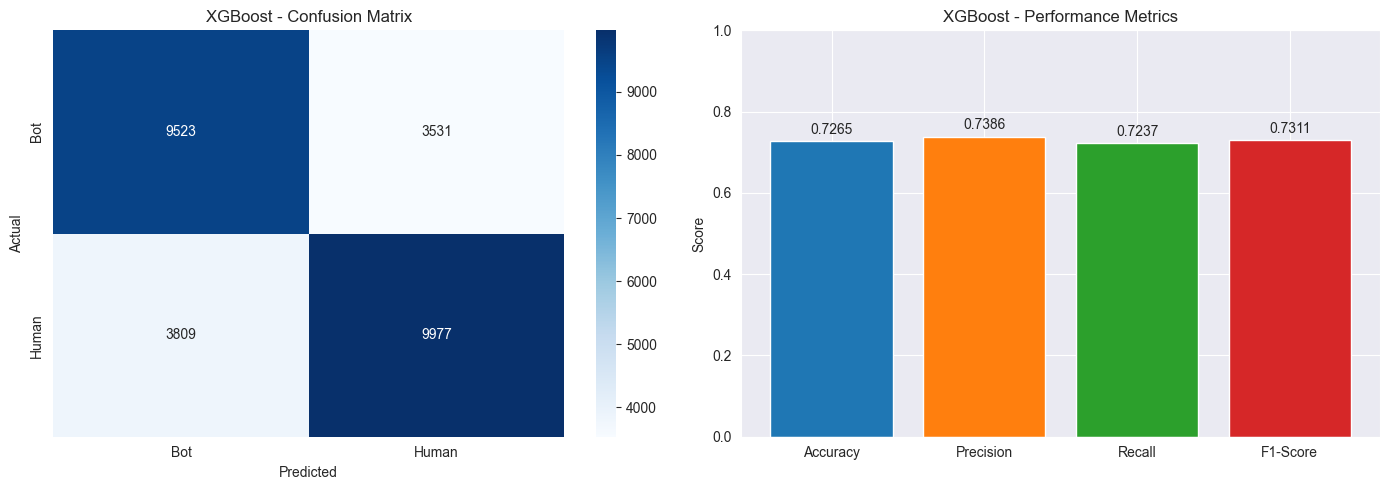

In [49]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('XGBoost - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Bot', 'Human'])
axes[0].set_yticklabels(['Bot', 'Human'])

# Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
bars = axes[1].bar(metrics, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_ylim(0, 1)
axes[1].set_title('XGBoost - Performance Metrics')
axes[1].set_ylabel('Score')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('xgboost_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
# Prepare data
numeric_cols = unbalanced_data.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['BinaryNumTarget', 'Unnamed:_0']  # Only exclude target and index
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

X = unbalanced_data[feature_cols].fillna(0)
y = unbalanced_data['BinaryNumTarget']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train LightGBM
print("Training LightGBM...")
model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

assert len(X) == len(y) == 134198, (len(X), len(y))
assert len(X_train) + len(X_test) == len(X)          # sanity on split
print("Unique index lengths:", X.index.nunique(), X_train.index.nunique(), X_test.index.nunique())

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nLightGBM Results:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Training LightGBM...
Unique index lengths: 134198 107358 26840

LightGBM Results:
Accuracy:  0.6933
Precision: 0.7080
Recall:    0.6856
F1-Score:  0.6966


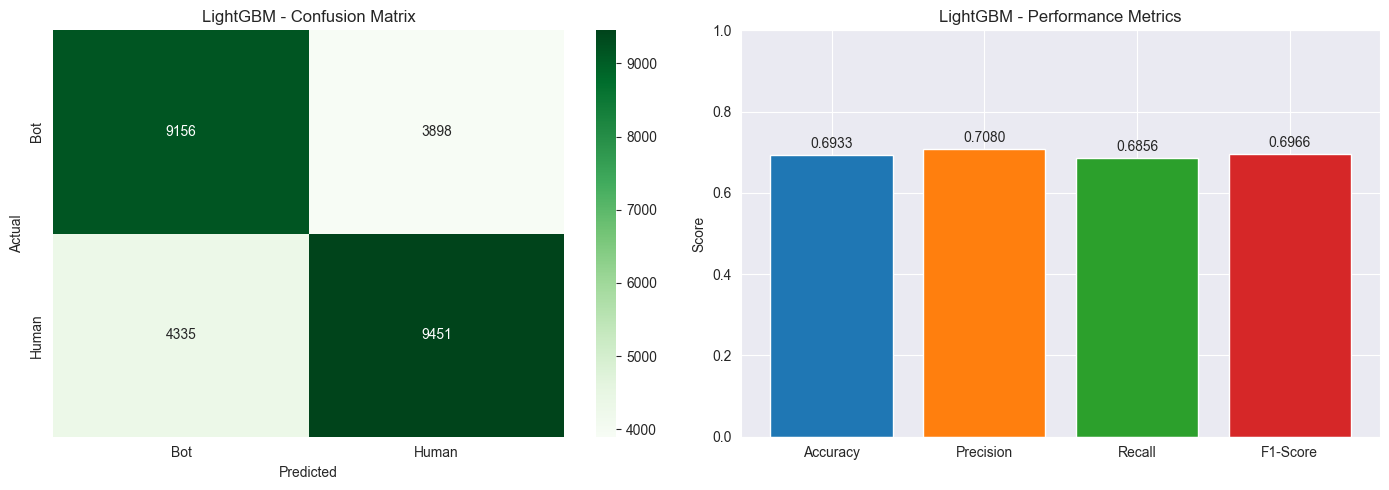

In [53]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('LightGBM - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Bot', 'Human'])
axes[0].set_yticklabels(['Bot', 'Human'])

# Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
bars = axes[1].bar(metrics, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_ylim(0, 1)
axes[1].set_title('LightGBM - Performance Metrics')
axes[1].set_ylabel('Score')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('lightgbm_results.png', dpi=300, bbox_inches='tight')
plt.show()

## Synthetic Results twin

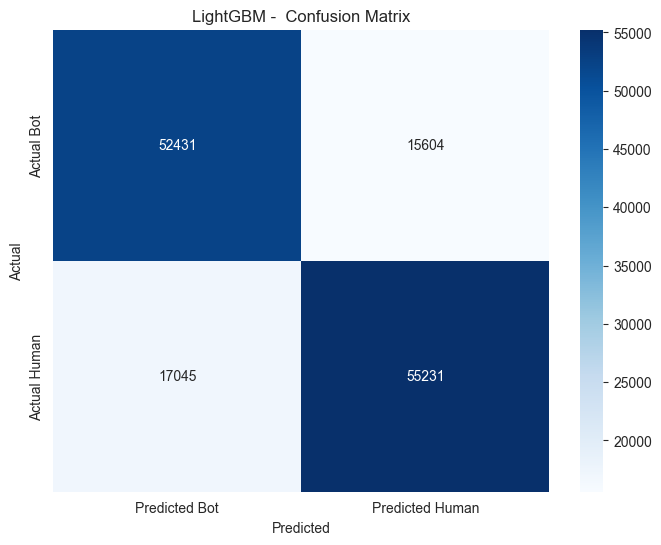

Accuracy:  0.7673
Precision: 0.7706
Recall:    0.7547
F1-score:  0.7626


C:\Users\alfar\AppData\Local\Temp\ipykernel_44520\4177529189.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='muted')


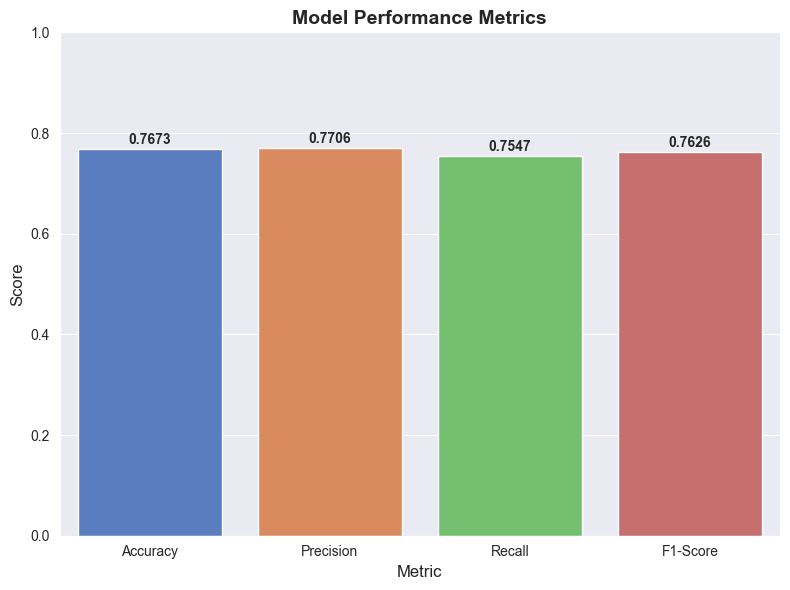

In [60]:
TP = 52431
TN = 55231
FP = 15604
FN = 17045

# Build matrix
cm_custom = np.array([[TP, FP],
                      [FN, TN]])

# Create labeled DataFrame
cm_df = pd.DataFrame(cm_custom,
                     index=['Actual Bot', 'Actual Human'],
                     columns=['Predicted Bot', 'Predicted Human'])

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title("LightGBM -  Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

accuracy = (TP + TN) / cm_custom.sum()
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

plt.figure(figsize=(8,6))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='muted')
plt.ylim(0, 1)
plt.title("Model Performance Metrics", fontsize=14, weight='bold')
plt.ylabel("Score", fontsize=12)
plt.xlabel("Metric", fontsize=12)

# Add value labels on bars
for i, val in enumerate(metrics.values()):
    plt.text(i, val + 0.01, f"{val:.4f}", ha='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()


## Showcase Distribution of Humans and Bots
- List of Humans and Bots accordingly

In [30]:
unbalanced_data['username'].head()

0    
1    
2    
3    
4    
Name: username, dtype: object

In [29]:
human_bot_csv = pd.read_csv('E:/tvb_25/ML_model/bot_human_predictions.csv')
human_bot_csv.head()

,username,predicted_class,confidence,bot_probability,human_probability,actual_class,actual_label,predicted_label
0,NaN,Human,99.972230,0.027770,99.972230,Human,1.0,1
1,NaN,Human,99.894450,0.105554,99.894450,Human,1.0,1
2,NaN,Human,99.889145,0.110859,99.889145,Human,1.0,1
3,NaN,Human,99.871400,0.128603,99.871400,Human,1.0,1
4,NaN,Human,99.862305,0.137699,99.862305,Human,1.0,1


In [33]:
human_bot_csv['predicted_class'].value_counts()

predicted_class
Human    13508
Bot      13332
Name: count, dtype: int64